# 04 — Model Baseline (ResNet-18)

In [ ]:
# --- Setup ---
import sys
sys.path.append('/content/drive/MyDrive/deepfake-detection')
from google.colab import drive
drive.mount('/content/drive')
from configs.paths import *

### Model + training pipeline

In [151]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [152]:
USE_SUBSET = True

if USE_SUBSET:
    train_df_model = train_df.sample(min(1000, len(train_df)), random_state=42).reset_index(drop=True)
    val_df_model   = val_df.sample(min(300, len(val_df)), random_state=42).reset_index(drop=True)
    test_df_model  = test_df.sample(min(300, len(test_df)), random_state=42).reset_index(drop=True)
else:
    train_df_model = train_df.copy().reset_index(drop=True)
    val_df_model   = val_df.copy().reset_index(drop=True)
    test_df_model  = test_df.copy().reset_index(drop=True)

print("Train samples:", len(train_df_model))
print("Val samples  :", len(val_df_model))
print("Test samples :", len(test_df_model))

Train samples: 1000
Val samples  : 300
Test samples : 300


In [153]:
train_dataset = DeepfakeBinaryDataset(
    train_df_model,
    num_frames=NUM_FRAMES,
    frames_root=FRAMES_ROOT

)

val_dataset = DeepfakeBinaryDataset(
    val_df_model,
    num_frames=NUM_FRAMES,
    frames_root=FRAMES_ROOT

)

test_dataset = DeepfakeBinaryDataset(
    test_df_model,
    num_frames=NUM_FRAMES,
    frames_root=FRAMES_ROOT

)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 1000
Val dataset  : 300
Test dataset : 300


In [154]:
BATCH_SIZE = 16
NUM_WORKERS = 4   # safer in Colab for video loading

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train loader batches:", len(train_loader))
print("Val loader batches  :", len(val_loader))
print("Test loader batches :", len(test_loader))

Train loader batches: 63
Val loader batches  : 19
Test loader batches : 19


In [155]:
train_class_counts = train_df_model["binary_target"].value_counts().sort_index().to_dict()
val_class_counts = val_df_model["binary_target"].value_counts().sort_index().to_dict()
test_class_counts = test_df_model["binary_target"].value_counts().sort_index().to_dict()

print("Train class counts:", train_class_counts)
print("Val class counts  :", val_class_counts)
print("Test class counts :", test_class_counts)

Train class counts: {0: 183, 1: 817}
Val class counts  : {0: 50, 1: 250}
Test class counts : {0: 50, 1: 250}


In [156]:
num_real = train_class_counts.get(0, 0)
num_fake = train_class_counts.get(1, 0)

total = num_real + num_fake

class_weights = torch.tensor(
    [
        total / (2 * max(num_real, 1)),   # weight for real
        total / (2 * max(num_fake, 1))    # weight for fake
    ],
    dtype=torch.float32
).to(device)

print("Class weights:", class_weights)

Class weights: tensor([2.7322, 0.6120], device='cuda:0')


In [157]:
import time
import copy
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [158]:
class ResNetBinaryVideoClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        features = self.feature_extractor(x)   # (B*T, 512, 1, 1)
        features = features.flatten(1)         # (B*T, 512)

        features = features.view(B, T, 512)    # (B, T, 512)
        video_features = features.mean(dim=1)  # temporal average pooling

        video_features = self.dropout(video_features)
        logits = self.classifier(video_features)

        return logits

In [159]:
model = ResNetBinaryVideoClassifier(dropout=0.3).to(device)
print(model)

ResNetBinaryVideoClassifier(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

In [160]:
batch_frames, batch_labels = next(iter(train_loader))

batch_frames = batch_frames.to(device)
batch_labels = batch_labels.to(device)

with torch.no_grad():
    outputs = model(batch_frames)

print("Input shape :", batch_frames.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", batch_labels.shape)

Input shape : torch.Size([16, 16, 3, 224, 224])
Output shape: torch.Size([16, 2])
Labels shape: torch.Size([16])


In [161]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Loss, optimizer, and scheduler initialized.")

Loss, optimizer, and scheduler initialized.


In [162]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [163]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    for frames, labels in loader:
        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(frames)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.detach().cpu().numpy())

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, zero_division=0)
    if len(set(all_labels)) > 1:
      epoch_auc = roc_auc_score(all_labels, all_probs)
    else:
      epoch_auc = 0.0

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, epoch_auc

In [164]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(frames)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, zero_division=0)
    epoch_f1 = f1_score(all_labels, all_preds, zero_division=0)

    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, epoch_f1, all_labels, all_preds, all_probs

In [167]:
EPOCHS = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "train_precision": [],
    "train_recall": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}

best_val_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device)

    train_loss, train_acc, train_precision, train_recall, train_f1, _ = train_metrics
    val_loss, val_acc, val_precision, val_recall, val_f1, _, _, _ = val_metrics

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_precision"].append(train_precision)
    history["train_recall"].append(train_recall)
    history["train_f1"].append(train_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_precision"].append(val_precision)
    history["val_recall"].append(val_recall)
    history["val_f1"].append(val_f1)

    # scheduler.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())

    epoch_time = time.time() - epoch_start

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f} | F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Epoch Time: {epoch_time/60:.2f} minutes")
    print("-" * 80)

total_time = time.time() - start_time
print(f"Total training time: {total_time/60:.2f} minutes")

Epoch [1/15]
Train Loss: 0.3129 | Acc: 0.8730 | Precision: 0.9688 | Recall: 0.8727 | F1: 0.9182
Val   Loss: 0.5114 | Acc: 0.7967 | Precision: 0.9276 | Recall: 0.8200 | F1: 0.8705
LR: 0.000100
Epoch Time: 1.40 minutes
--------------------------------------------------------------------------------
Epoch [2/15]
Train Loss: 0.2073 | Acc: 0.9130 | Precision: 0.9790 | Recall: 0.9131 | F1: 0.9449
Val   Loss: 0.5520 | Acc: 0.7467 | Precision: 0.9394 | Recall: 0.7440 | F1: 0.8304
LR: 0.000100
Epoch Time: 1.40 minutes
--------------------------------------------------------------------------------
Epoch [3/15]
Train Loss: 0.1809 | Acc: 0.9270 | Precision: 0.9869 | Recall: 0.9229 | F1: 0.9538
Val   Loss: 0.7142 | Acc: 0.6667 | Precision: 0.9688 | Recall: 0.6200 | F1: 0.7561
LR: 0.000100
Epoch Time: 1.40 minutes
--------------------------------------------------------------------------------
Epoch [4/15]
Train Loss: 0.1663 | Acc: 0.9320 | Precision: 0.9807 | Recall: 0.9351 | F1: 0.9574
Val   Loss

In [168]:
model.load_state_dict(best_model_wts)
print("Best model weights loaded.")
print("Best validation F1:", best_val_f1)

Best model weights loaded.
Best validation F1: 0.9366053169734151


In [169]:
test_metrics = evaluate(model, test_loader, criterion, device)
test_loss, test_acc, test_precision, test_recall, test_f1, y_true, y_pred, y_prob = test_metrics

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")

Test Loss     : 0.6464
Test Accuracy : 0.8600
Test Precision: 0.9522
Test Recall   : 0.8760
Test F1-score : 0.9125


In [170]:
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["real", "fake"],
    zero_division=0
))

Classification Report:

              precision    recall  f1-score   support

        real       0.56      0.78      0.65        50
        fake       0.95      0.88      0.91       250

    accuracy                           0.86       300
   macro avg       0.75      0.83      0.78       300
weighted avg       0.89      0.86      0.87       300



In [171]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 39  11]
 [ 31 219]]


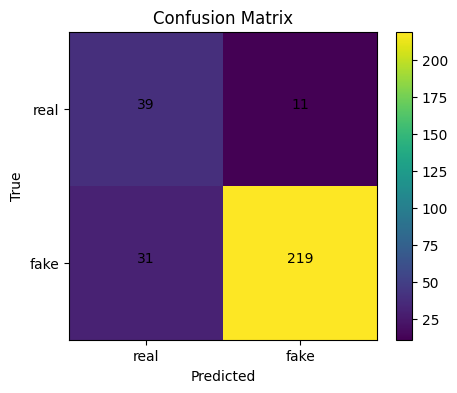

In [172]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["real","fake"])
plt.yticks(tick_marks, ["real","fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,str(cm[i,j]),ha="center")

plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

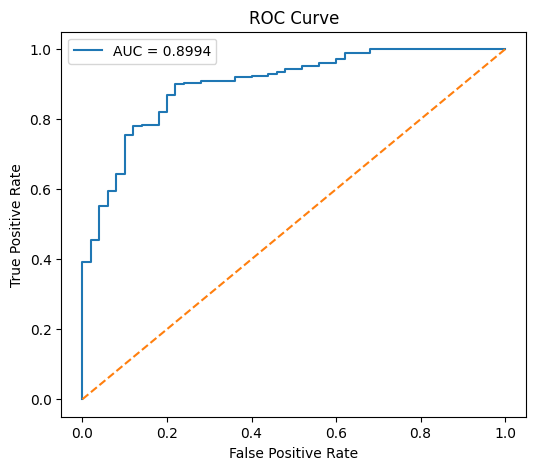

In [174]:
from sklearn.metrics import roc_curve, roc_auc_score

# compute ROC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

# compute AUC
test_auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

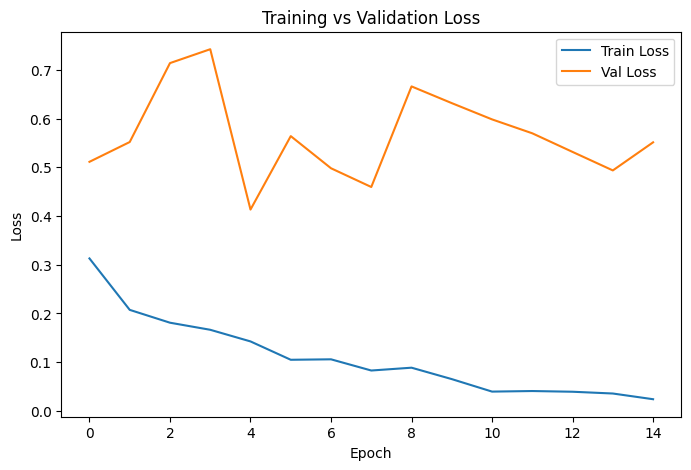

In [175]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

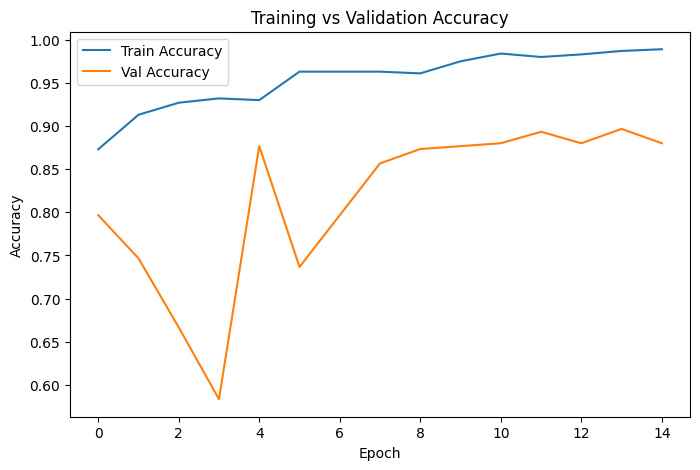

In [176]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

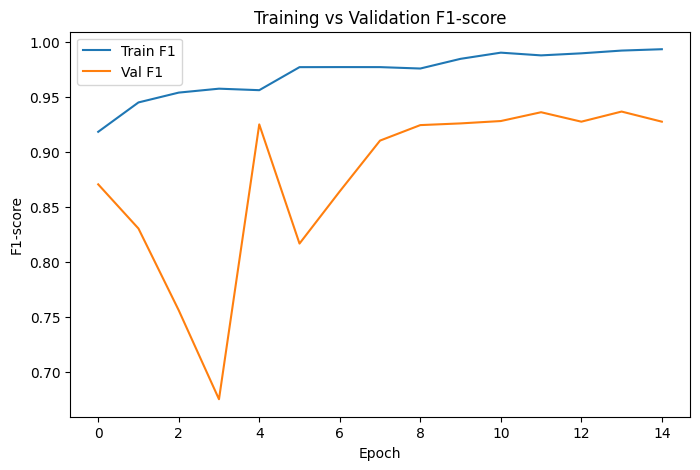

In [177]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

In [178]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "resnet18_binary_deepfake_detector_best.pth"
torch.save(model.state_dict(), model_path)

print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/binary_deepfake_detection/models/resnet18_binary_deepfake_detector_best.pth


In [179]:
summary = {
    "best_val_f1": float(best_val_f1),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "num_frames": NUM_FRAMES,
    "img_size": IMG_SIZE,
    "use_subset": USE_SUBSET
}

print(summary)

{'best_val_f1': 0.9366053169734151, 'test_loss': 0.6463747822244962, 'test_accuracy': 0.86, 'test_precision': 0.9521739130434783, 'test_recall': 0.876, 'test_f1': 0.9125, 'epochs': 15, 'batch_size': 16, 'num_frames': 16, 'img_size': 224, 'use_subset': True}
